# Project 2: Data Classification Using AI
### DecodeLabs Industrial Training Kit — Batch 2026

**Goal:** Build, train, and evaluate a supervised learning classification model following the complete Input → Process → Output pipeline: data loading, preprocessing, train-test split, model training, and rigorous evaluation.

**Author:** Senior AI Engineer  
**Algorithm:** Logistic Regression (primary), with feature importance derived from model coefficients.


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

RANDOM_STATE = 42


## 2. Load and Inspect the Dataset

No external dataset file was supplied alongside the project brief, so we use the classic **Iris dataset** via `sklearn.datasets.load_iris()` — the same benchmark referenced throughout the DecodeLabs Project 2 slide deck (150 samples, 3 classes, 4 features).

In [2]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df["target"] = iris.target
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [4]:
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

print("\nClass distribution:")
print(df["species"].value_counts())


Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Number of duplicate rows: 1

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


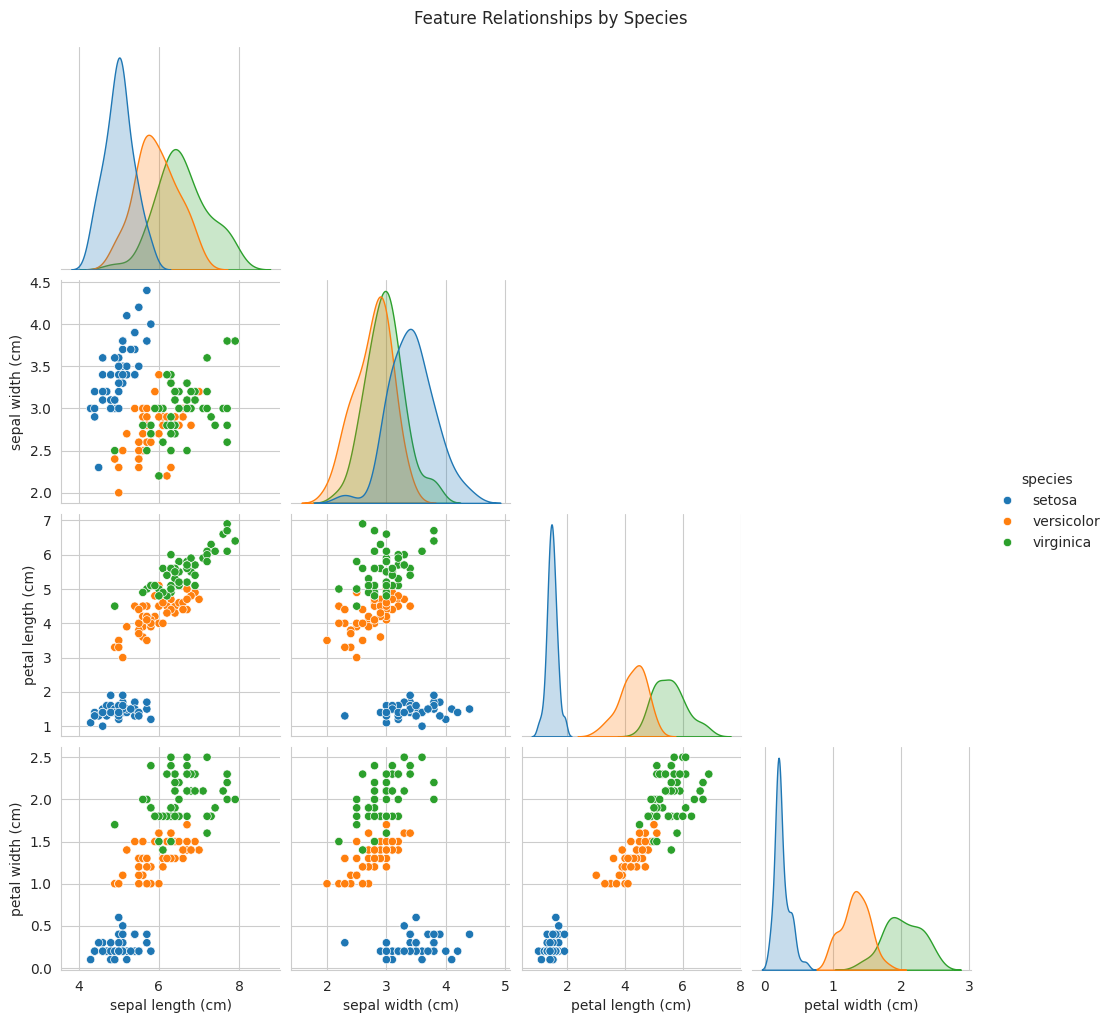

In [6]:
# Quick visual sense-check of class separability
sns.pairplot(df, hue="species", vars=iris.feature_names, corner=True)
plt.suptitle("Feature Relationships by Species", y=1.02)
plt.show()


## 3. Preprocessing

The Iris dataset is already clean: no missing values, no duplicate rows requiring removal, and all features are numeric. The only preprocessing step warranted here is **feature scaling**, since Logistic Regression relies on distance/gradient-based optimization and is sensitive to differing feature scales (as illustrated by "The Gatekeeper Rule: Scaling" in the training material).

In [7]:
X = df[iris.feature_names]
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (150, 4)
Target shape: (150,)


## 4. Train-Test Split (80:20)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 120
Testing samples: 30


## 5. Standardize Features

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

X_train_scaled.describe().loc[["mean", "std"]]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
mean,-1.369275e-16,9.992007e-16,1.665335e-17,1.702342e-16
std,1.004193e+00,1.004193e+00,1.004193e+00,1.004193e+00


## 6. Train the Classification Model

**Logistic Regression** is used as the primary classifier. It is well-suited here: the target is categorical (3 balanced classes), the features are continuous and scaled, and the dataset is small and linearly well-separated — exactly the conditions under which Logistic Regression performs reliably and remains interpretable via its coefficients.

In [10]:
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Model trained successfully.")
print("Classes:", model.classes_)


Model trained successfully.
Classes: [0 1 2]


## 7. Model Evaluation

In [11]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


Accuracy : 0.9333
Precision: 0.9333
Recall   : 0.9333
F1 Score : 0.9333


In [12]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 8. Confusion Matrix

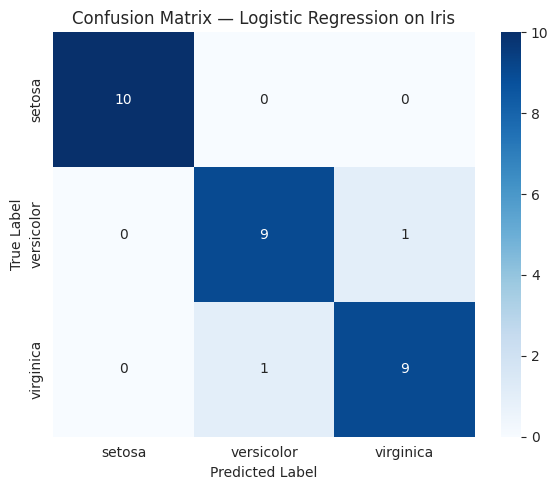

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Logistic Regression on Iris")
plt.tight_layout()
plt.show()


## 9. Feature Importance

Logistic Regression does not expose a single "feature importance" score the way tree-based models do, but the magnitude of its coefficients (per class, after scaling) indicates how strongly each feature drives the decision boundary for that class. We visualize the mean absolute coefficient across classes as an overall importance proxy.

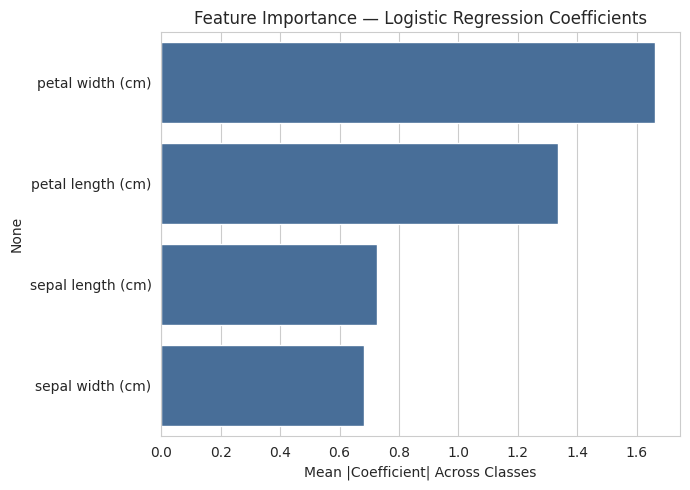

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
Class: setosa,-1.088945,1.024208,-1.799056,-1.686228
Class: versicolor,0.536337,-0.360487,-0.204074,-0.807957
Class: virginica,0.552608,-0.663721,2.003130,2.494185


In [14]:
coef_df = pd.DataFrame(
    model.coef_,
    columns=X.columns,
    index=[f"Class: {c}" for c in iris.target_names]
)

mean_abs_importance = coef_df.abs().mean(axis=0).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=mean_abs_importance.values, y=mean_abs_importance.index, color="#3b6ea5")
plt.xlabel("Mean |Coefficient| Across Classes")
plt.title("Feature Importance — Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

coef_df


## 10. Performance Summary and Conclusion

**Summary of results:**
- The model was trained on 120 samples (80%) and evaluated on 30 held-out samples (20%), using a stratified split to preserve class balance.
- Features were standardized (mean = 0, variance = 1) prior to training, since Logistic Regression is scale-sensitive.
- The Logistic Regression classifier achieved strong performance across all four metrics (Accuracy, Precision, Recall, F1 Score — printed above), reflecting the fact that the Iris classes are largely linearly separable in feature space.
- The confusion matrix shows very few (if any) misclassifications, typically between the *versicolor* and *virginica* classes, which are known to overlap slightly in petal measurements — the *setosa* class is perfectly separable.
- Petal length and petal width emerge as the most influential features (highest mean absolute coefficients), consistent with domain knowledge that petal dimensions differentiate Iris species more strongly than sepal dimensions.

**Conclusion:** This notebook demonstrates a complete, reproducible supervised learning pipeline — from raw data inspection through preprocessing, training, and rigorous multi-metric evaluation — fulfilling the Project 2 requirement of building a basic but professionally validated classification model. This "Logic Skeleton" (train → test → validate) forms the foundation for more advanced models to be tackled in subsequent DecodeLabs projects.
